<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DES VENTES DU SITE DE LIBRAIRIE LAPAGE</h1>
</div>

## Objectif: Etudier des KPIs de la librairie LAPAGE afin de pouvoir suivre le marché et adapter les stratégies de vente en ligne


La librairie physique LAPAGE, en pleine croissance, souhaite mettre en ligne la vente de ses livres. En conséquence, l’équipe Marketing souhaite suivre l’évolution du marché afin d’adapter ses stratégies de vente en ligne et de mieux comprendre les comportements des clients.

L’objectif de ce notebook est donc, à partir de leurs données, de réaliser des analyses portant sur :

- **les principaux indicateurs de vente (KPI) et des chiffres clés**
    - Chiffre d’affaires avec moyenne mobile par mois, par jour
    - Chiffre d’affaires par catégorie
    - Nombre de clients par jour
    - Nombre de transactions
    - Nombre de produits vendus
    
- **les produits vendus** 
    - Top produits, Flop produits
    - Répartition par catégorie
    - Courbe de Lorenz
    
- **les profils des clients afin de comprendre leurs comportements**
    - Répartition du chiffre d'affaires pour les clients BtoB
    - Top clients et Flop Clients
    - Corrélation entre :
        - Genre & catégories des livres achetés
        - Age des clients & montant total des achats
        - Age des clients & fréquence d’achat
        - Age des clients & taille du panier moyen
        - Age des clients & catégorie des livres achetés;

Les résultats et recommandations seront présentés au COPIR (Comité de Pilotage) et au CODIR (Comité de Direction).

**Plan**

Afin de réaliser ces analyses, nous allons procéder selon les étapes suivantes :
- Nettoyage et transformation des données
- Analyse exploratoire des données
- Tests statistiques

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

In [561]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import datetime 
import seaborn as sns
from scipy.stats import norm
from scipy.stats import kstest
from scipy.stats import shapiro

In [562]:
# Importation 
# Infos de transactions
transaction = pd.read_csv("transactions.csv")

# Infos des clients
customer = pd.read_csv("customers.csv")

# Infos des produits
product = pd.read_csv("products.csv")

 <div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Découvrir et transformation des données </h2>
</div>

Dans un premier temps, nous allons examiner la qualité des données en observant :
- les valeurs manquantes,
- l’unicité des identifiants dans le fichier,
- les valeurs aberrantes,
- la conformité des données (types, formats).

 <div style="background-color: RGB(51,100,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Etape 2.1 - Analyse exploratoire du fichier "transaction" </h3>
</div>

In [563]:
# Lecture transaction
print(transaction.info(), "\nIl n'y a pas de valeur nulle")
print(transaction.dtypes, "\nLe type de la colonne date est à modifier")
print("Les données \"transaction\" contiennent à l'origine ", transaction.shape[0], "lignes et ", transaction.shape[1], " colonnes")

print("Le nombre de transaction unique est de : \n", transaction.drop_duplicates(subset = ["session_id"]).shape[0])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679532 entries, 0 to 679531
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     679532 non-null  object
 1   date        679532 non-null  object
 2   session_id  679532 non-null  object
 3   client_id   679532 non-null  object
dtypes: object(4)
memory usage: 20.7+ MB
None 
Il n'y a pas de valeur nulle
id_prod       object
date          object
session_id    object
client_id     object
dtype: object 
Le type de la colonne date est à modifier
Les données "transaction" contiennent à l'origine  679532 lignes et  4  colonnes
Le nombre de transaction unique est de : 
 342316


In [564]:
# Vérifier la conformité des dates 
# to_datatime
transaction1 = transaction.copy()
transaction1["date"] = pd.to_datetime(transaction1["date"], errors='coerce')

# les dates non conformes deviennent vides
date_na = transaction1.loc[transaction1["date"].isna()].shape[0]
print("Il existe {} lignes non conforme".format(date_na))

transaction.loc[transaction1["date"].isna()]

Il existe 200 lignes non conforme


,id_prod,date,session_id,client_id
3019,T_0,test_2021-03-01 02:30:02.237419,s_0,ct_0
5138,T_0,test_2021-03-01 02:30:02.237425,s_0,ct_0
9668,T_0,test_2021-03-01 02:30:02.237437,s_0,ct_1
10728,T_0,test_2021-03-01 02:30:02.237436,s_0,ct_0
15292,T_0,test_2021-03-01 02:30:02.237430,s_0,ct_0
...,...,...,...,...
657830,T_0,test_2021-03-01 02:30:02.237417,s_0,ct_0
662081,T_0,test_2021-03-01 02:30:02.237427,s_0,ct_1
670680,T_0,test_2021-03-01 02:30:02.237449,s_0,ct_1
671647,T_0,test_2021-03-01 02:30:02.237424,s_0,ct_1


In [565]:
# Enlève les dates non conformes test_
transaction1 = transaction[~transaction["date"].str.contains("test_", case=False)].reset_index()

# Corrige le type de variable date
transaction1["date"] = pd.to_datetime(transaction1["date"], errors='coerce')

# les dates non formes sont exclues
transaction1.loc[transaction1["date"].isna()]
print("Il n'y a plus de date non conforme")

print("Il n'y a plus d'informité dans la variable id_prod : ", transaction1[transaction1["id_prod"].str.contains("T_", case=False)].shape[0])
print("Il n'y a plus d'informité dans la variable  client_id : ", transaction1[transaction1["client_id"].str.contains("ct_", case=False)].shape[0])


Il n'y a plus de date non conforme
Il n'y a plus d'informité dans la variable id_prod :  0
Il n'y a plus d'informité dans la variable  client_id :  0


In [566]:
print(transaction1.info(), "\nIl n'y a pas de valeur nulle")
print(transaction1.dtypes, "\nLe type de la colonne date est à modifier")
print("Les données \"transaction\" contiennent maintenant ", transaction1.shape[0], "lignes et ", transaction1.shape[1], " colonnes")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679332 entries, 0 to 679331
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   index       679332 non-null  int64         
 1   id_prod     679332 non-null  object        
 2   date        679332 non-null  datetime64[ns]
 3   session_id  679332 non-null  object        
 4   client_id   679332 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 25.9+ MB
None 
Il n'y a pas de valeur nulle
index                  int64
id_prod               object
date          datetime64[ns]
session_id            object
client_id             object
dtype: object 
Le type de la colonne date est à modifier
Les données "transaction" contiennent maintenant  679332 lignes et  5  colonnes


In [567]:
# Chercher les doublons 
transaction2 = transaction1.copy()
transaction2["date_court"] = transaction2["date"].astype("str").str[:10]
transaction2["date_court"] = pd.to_datetime(transaction2["date_court"], errors='coerce')
transaction2[transaction2.duplicated(subset=["session_id", "id_prod", "client_id", "date"])]

print("{} lignes dupliqués. Pas de doublons sur l'ensemble des colonnes : session_id, id_prod, client_id, date !".format(transaction2[transaction2.duplicated(subset=["session_id", "id_prod", "client_id", "date"])].shape[0]))

0 lignes dupliqués. Pas de doublons sur l'ensemble des colonnes : session_id, id_prod, client_id, date !


In [568]:
# Ajouter des colonnes
transaction2["year"] = transaction2["date"].dt.year
transaction2["quarter"] = transaction2["date"].dt.quarter
transaction2["month"] = transaction2["date"].dt.month

print(transaction2.info())
transaction2.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679332 entries, 0 to 679331
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   index       679332 non-null  int64         
 1   id_prod     679332 non-null  object        
 2   date        679332 non-null  datetime64[ns]
 3   session_id  679332 non-null  object        
 4   client_id   679332 non-null  object        
 5   date_court  679332 non-null  datetime64[ns]
 6   year        679332 non-null  int64         
 7   quarter     679332 non-null  int64         
 8   month       679332 non-null  int64         
dtypes: datetime64[ns](2), int64(4), object(3)
memory usage: 46.6+ MB
None


,index,id_prod,date,session_id,client_id,date_court,year,quarter,month
0,0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,2022-05-20,2022,2,5
1,1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,2022-02-02,2022,1,2
2,2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,2022-06-18,2022,2,6
3,3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,2021-06-24,2021,2,6
4,4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,2023-01-11,2023,1,1


### Etude de la tendance des transactions (détection des anomalies)

In [569]:
# Trier les données par date 
tend_nbTrans = (
    transaction2
    .sort_values("date_court")
    .groupby("date_court")
    .agg(Nombre_trans=("session_id", "nunique"))
    .reset_index()
)

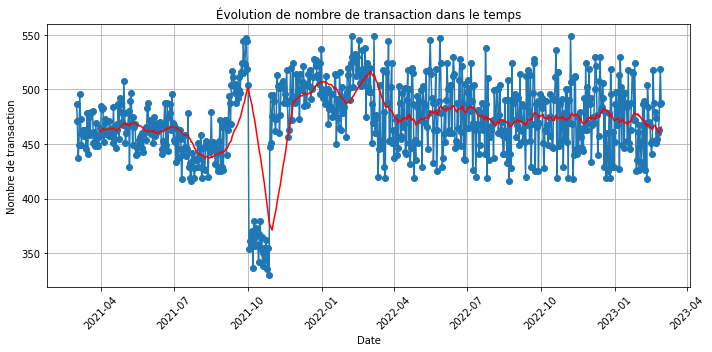

In [570]:
# Tracer l'évolution
plt.figure(figsize=(10, 5))
plt.plot(tend_nbTrans["date_court"], tend_nbTrans["Nombre_trans"], marker='o')
plt.plot(tend_nbTrans["date_court"], tend_nbTrans["Nombre_trans"].rolling(30).mean(), linestyle='-', color='red', label="Moyenne mobile 30 jours")

plt.title('Évolution de nombre de transaction dans le temps')
plt.xlabel('Date')
plt.ylabel('Nombre de transaction')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Remarques :**

On observe une forte augmentation des transactions en septembre, passant de 450 à 550, suivie d’une nette diminution des ventes en octobre, de 550 à 350, puis une stabilisation autour de 450 à 480 transactions par la suite.

<div style="background-color: RGB(51,100,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Etape 2.2 - Analyse exploratoire du fichier "customer" </h3>
</div>

In [571]:
# Customer
print(customer.info(), "\nIl n'y a pas de valeur nulle")
print(customer.dtypes, "\n Pas de type de colonne à modifier\n")
print("Le nombre de client unique est de : {}. Les identifiants des clients sont uniques".format(customer[["client_id"]].shape[0]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8623 entries, 0 to 8622
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8623 non-null   object
 1   sex        8623 non-null   object
 2   birth      8623 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB
None 
Il n'y a pas de valeur nulle
client_id    object
sex          object
birth         int64
dtype: object 
 Pas de type de colonne à modifier

Le nombre de client unique est de : 8623. Les identifiants des clients sont uniques


In [572]:
customer.head(5) 
# format de saisie de "client_id" est fixe "c_[number]""

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [573]:
# Le client_id valide ?
nb_client_valid = customer[~customer["client_id"].str.contains("c_", case=False)]
print("Il existe {} clients non conforme".format(nb_client_valid.shape[0]))

# Enlever ces faux client_id 
customer = customer[customer["client_id"].str.contains("c_", case=False)]

nb_client_valid

Il existe 2 clients non conforme


,client_id,sex,birth
2735,ct_0,f,2001
8494,ct_1,m,2001


In [574]:
# Calcul de l'âge des clients
current = datetime.date.today()
print("Année encours est : ", current.year)

customer1 = customer.copy()
customer1["Age"] = current.year - customer["birth"]

customer1.info()
print("Le nombre de client unique et valide est de : {}. Les identifiants des clients sont uniques".format(customer[["client_id"]].shape[0]))

Année encours est :  2025
<class 'pandas.core.frame.DataFrame'>
Int64Index: 8621 entries, 0 to 8622
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
 3   Age        8621 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 336.8+ KB
Le nombre de client unique et valide est de : 8621. Les identifiants des clients sont uniques


### Etude exploratoire de la variable "Age" (Détection des anomalies)

In [575]:
# Méthode de détection des outliers
def detect_outliers(df, feature) : 
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3-Q1
    
    return(df[feature]< (Q1 - 2*IQR)) | (df[feature]> (Q3 + 2*IQR))


In [576]:
# Outliers de l'age 
# Valeurs aberrantes
print("Le nombre de lignes aberrant : ", customer1.loc[customer1["Age"]<0, "client_id"].shape[0])

# Valeurs atypiques
print("Il y a {} valeurs atypiques".format(customer1[detect_outliers(customer1, "Age")].shape[0]))

customer1[detect_outliers(customer1, "Age")]

Le nombre de lignes aberrant :  0
Il y a 0 valeurs atypiques


,client_id,sex,birth,Age


In [577]:
print("Il existe {} genres chez les clients.".format(customer1["sex"].nunique()))

Il existe 2 genres chez les clients.


### Jointure pour la validation de cohérence entre les tables transaction & client

In [578]:
# Jointure gauche entre transaction & infos clients (parce qu'on veut connaitre les personnes qui ont acheté les produits)
trans_cust = pd.merge(transaction2, customer1, how="outer", left_on = "client_id", right_on = "client_id", indicator=True)
print("Vérifier les types de jointures existant : {}".format(trans_cust["_merge"].unique())) # s'assurer qu'il y a que both & right_only

transCust = trans_cust.loc[trans_cust["_merge"]=="both"]
transCust = transCust.drop("_merge", axis=1)

transCust.info()

Vérifier les types de jointures existant : ['both', 'right_only']
Categories (2, object): ['both', 'right_only']
<class 'pandas.core.frame.DataFrame'>
Int64Index: 679332 entries, 0 to 679331
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   index       679332 non-null  float64       
 1   id_prod     679332 non-null  object        
 2   date        679332 non-null  datetime64[ns]
 3   session_id  679332 non-null  object        
 4   client_id   679332 non-null  object        
 5   date_court  679332 non-null  datetime64[ns]
 6   year        679332 non-null  float64       
 7   quarter     679332 non-null  float64       
 8   month       679332 non-null  float64       
 9   sex         679332 non-null  object        
 10  birth       679332 non-null  int64         
 11  Age         679332 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(2), object(4)
memory usage: 67.4+ MB


**Remarques :** 

Il existe des clients qui n'ont pas encore réalisé de transaction d'après la jointure (right_only).

 <div style="background-color: RGB(51,100,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Etape 2.2 - Analyse exploratoire du fichier "product" </h3>
</div>

In [579]:
# Product
print(product.info(), "\nIl n'y a pas de valeur nulle")
print(product.dtypes, "\nLe type de colonne categ à modifier")
print("Le nombre de produit unique est de : {}. Donc, les identifiants des produits sont uniques".format(product.drop_duplicates(subset=["id_prod"]).shape[0]))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3287 non-null   object 
 1   price    3287 non-null   float64
 2   categ    3287 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.2+ KB
None 
Il n'y a pas de valeur nulle
id_prod     object
price      float64
categ        int64
dtype: object 
Le type de colonne categ à modifier
Le nombre de produit unique est de : 3287. Donc, les identifiants des produits sont uniques


In [580]:
product.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [581]:
# Produit valide ? 
nb_produit_Nonvalid = product[~((product["id_prod"].str.contains("0_", case=False)) |
           (product["id_prod"].str.contains("1_", case=False)) | 
           (product["id_prod"].str.contains("2_", case=False)))]                  
         
    
print("Il existe {} produit(s) non conforme en id_prod et en prix".format(nb_produit_Nonvalid.shape[0]))

nb_produit_Nonvalid

Il existe 1 produit(s) non conforme en id_prod et en prix


,id_prod,price,categ
731,T_0,-1.0,0


In [582]:
# Filtrer les anomalies
product = product[product["id_prod"]!="T_0"].reset_index() 

In [583]:
# transforme les types de colonne de product
product1 = product.copy()
product1["categ"] = product1["categ"].astype(str)

# Valeurs aberrantes
print("Le nombre de lignes aberrant : ", product1.loc[product1["price"]<0, "id_prod"].shape[0])

# Corrige en valeur positive
product1.loc[product1["price"]<0, "price"] = -product1.loc[product1["price"]<0, "price"]
print("Le nombre de lignes aberrant après modification : ", product1.loc[product1["price"]<0, "id_prod"].shape[0])


Le nombre de lignes aberrant :  0
Le nombre de lignes aberrant après modification :  0


In [584]:
print("{} lignes inconformes. Pas de id_prod non conforme".format(product1[~((product1["id_prod"].str.contains("0_", case=False)) |
           (product1["id_prod"].str.contains("1_", case=False)) | 
           (product1["id_prod"].str.contains("2_", case=False)))].shape[0]))

product1.head()

0 lignes inconformes. Pas de id_prod non conforme


,index,id_prod,price,categ
0,0,0_1421,19.99,0
1,1,0_1368,5.13,0
2,2,0_731,17.99,0
3,3,1_587,4.99,1
4,4,0_1507,3.99,0


In [585]:
# Outliers de price
print("Il y a {} prix atypiques dans les produits vendus".format(product1[detect_outliers(product1, "price")].shape[0]))
product1[detect_outliers(product1, "price")]

Il y a 250 prix atypiques dans les produits vendus


,index,id_prod,price,categ
10,10,2_228,225.17,2
38,38,2_100,72.11,2
64,64,2_89,107.99,2
73,73,2_225,157.99,2
79,79,2_187,157.99,2
...,...,...,...,...
3223,3224,1_276,56.97,1
3266,3267,2_101,63.99,2
3270,3271,2_123,147.99,2
3278,3279,1_331,55.99,1


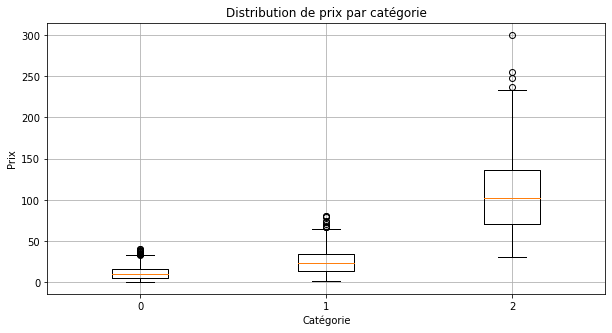

Peu de données hors fourchette de prix, donc acceptable


In [586]:
# Observation des valeurs atypiques
data = [group["price"].values for _, group in product1.groupby("categ")]

plt.figure(figsize=(10, 5))
plt.boxplot(data, labels=product1["categ"].unique())
plt.title('Distribution de prix par catégorie')
plt.xlabel('Catégorie')
plt.ylabel('Prix')
plt.grid(True)

# Enregistrer le graphique en PNG
plt.savefig("box_CA_categorie.png", dpi=300, bbox_inches='tight')
plt.show()


print("Peu de données hors fourchette de prix, donc acceptable")

### Jointure pour la validation de cohérence entre les données transaction & produit

In [587]:
# Jointure gauche entre transaction_clients & infos product (parce qu'on veut connaitre les produits vendus)
trans_prod = pd.merge(transaction2, product1, how="outer", left_on = "id_prod", right_on = "id_prod", indicator=True)

print(trans_prod["_merge"].unique()) # Existe un jointure gauche qui n'est pas cohérent


['both', 'left_only', 'right_only']
Categories (3, object): ['both', 'left_only', 'right_only']


La jointure gauche (left_only) montre qu’il existe des produits échangés sur le marché mais absents de la liste des produits. Il est donc nécessaire de les ajouter à la table afin d’assurer la cohérence entre les tables.

In [588]:
print("Il existe un produit qui n'est pas dans la liste des produits : ", 
      trans_prod.loc[trans_prod["_merge"]=="left_only", "id_prod"].unique()) #0_2245 (ajouter le prix moyen de la catéogie 0)


Il existe un produit qui n'est pas dans la liste des produits :  ['0_2245']


In [589]:
# Product 0_2245
print("Il y a {} lignes de produits : 0_2245 dans la table de données \"transaction\"".format(transaction2.loc[transaction2["id_prod"]=="0_2245"].shape[0]))


Il y a 221 lignes de produits : 0_2245 dans la table de données "transaction"


In [590]:
# Ajouter un produit 0_2245 dans la table des produits

# Trouver le prix moyen du produit de catégorie 0 & créer ce produit
prixmoy_cat0 = product1.loc[product1["categ"]=="0", "price"].mean()

new_prod = pd.DataFrame([{"index" : 3288,"id_prod": "0_2245", "price": prixmoy_cat0, "categ": "0"}])

product2 = pd.concat([product1, new_prod], ignore_index=True)

print("Le nombre de ligne d'origine est de", product1.shape[0])
print("Le nombre de ligne mise à jour est de", product2.shape[0])

Le nombre de ligne d'origine est de 3286
Le nombre de ligne mise à jour est de 3287


In [591]:
# Jointure après correction
trans_prod1 = pd.merge(transaction2, product2, how="outer", left_on = "id_prod", right_on = "id_prod", indicator=True)

print(trans_prod1["_merge"].unique()) 
print("Il existe {} produit(s) qui n'est pas dans la liste des produits : ".format( 
      trans_prod1.loc[trans_prod1["_merge"]=="left_only", "id_prod"].nunique()))

trans_prod2 = trans_prod1.loc[trans_prod1["_merge"]=="both"].reset_index()

# Verification de conformité de date
trans_prod2.loc[trans_prod2["date"].isna()]

['both', 'right_only']
Categories (2, object): ['both', 'right_only']
Il existe 0 produit(s) qui n'est pas dans la liste des produits : 


,index,index_x,id_prod,date,session_id,client_id,date_court,year,quarter,month,index_y,price,categ,_merge


In [592]:
trans_prod2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679332 entries, 0 to 679331
Data columns (total 14 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   index       679332 non-null  int64         
 1   index_x     679332 non-null  float64       
 2   id_prod     679332 non-null  object        
 3   date        679332 non-null  datetime64[ns]
 4   session_id  679332 non-null  object        
 5   client_id   679332 non-null  object        
 6   date_court  679332 non-null  datetime64[ns]
 7   year        679332 non-null  float64       
 8   quarter     679332 non-null  float64       
 9   month       679332 non-null  float64       
 10  index_y     679332 non-null  int64         
 11  price       679332 non-null  float64       
 12  categ       679332 non-null  object        
 13  _merge      679332 non-null  category      
dtypes: category(1), datetime64[ns](2), float64(5), int64(2), object(4)
memory usage: 68.0+ MB


In [593]:
# Figure obtenu selon differents categorie
tend_nbTrans_cat = (
    trans_prod2
    .sort_values("date_court")
    .groupby(["date_court", "categ"])
    .agg(Nombre_trans=("session_id", "nunique"), 
        CA = ("price", "sum"))
    .reset_index()
)
tend_nbTrans_cat["CA_moymob"] = tend_nbTrans_cat["CA"].rolling(30).mean()

tend_nbTrans_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2164 entries, 0 to 2163
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date_court    2164 non-null   datetime64[ns]
 1   categ         2164 non-null   object        
 2   Nombre_trans  2164 non-null   int64         
 3   CA            2164 non-null   float64       
 4   CA_moymob     2135 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 84.7+ KB


In [594]:
tend_nbTrans_cat.loc[(tend_nbTrans_cat["categ"]=="2") & (tend_nbTrans_cat["date_court"]>"2022-02-01")]

,date_court,categ,Nombre_trans,CA,CA_moymob
990,2022-02-02,2,51,4786.20,5774.786426
993,2022-02-03,2,47,4294.45,5801.654093
996,2022-02-04,2,53,5167.94,5923.783760
999,2022-02-05,2,48,4932.23,5991.174000
1002,2022-02-06,2,54,5002.79,6098.737000
...,...,...,...,...,...
2151,2023-02-24,2,39,3538.90,5423.638373
2154,2023-02-25,2,39,2767.95,5425.623039
2157,2023-02-26,2,43,3772.73,5442.238946
2160,2023-02-27,2,55,5271.62,5555.665426


##### Nombre de transactions par catégorie

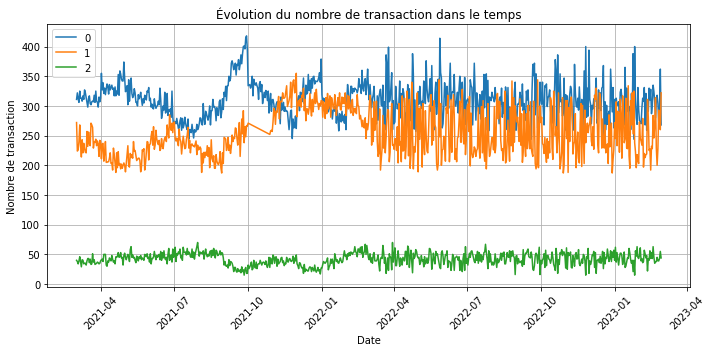

In [595]:
# Nombre de transaction par catégorie
plt.figure(figsize=(10, 5))

sns.lineplot(data=tend_nbTrans_cat, x="date_court", y="Nombre_trans", hue="categ")

plt.title("Évolution du nombre de transaction dans le temps")
plt.xlabel('Date')
plt.ylabel("Nombre de transaction")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()

# Enregistrer le graphique en PNG
plt.savefig("Evolution_Trans.png", dpi=300, bbox_inches='tight')

plt.show()

D'une manière globale :
- Le nombre de transactions est faible pour la catégorie 2, mais il reste stable à environ 40 sur toute la période.
- Le nombre de transactions se stabilise autour de 200 à 300 pour la catégorie 1.
- Le nombre de transactions varie entre 300 et 350 pour la catégorie 0.

Entre septembre et novembre 2021 :
- Le nombre de transactions pour le produit de catégorie 0 a connu une forte variation, passant d’environ 400 à 250 (hausse puis baisse).
- Le nombre de transactions pour la catégorie 1 a augmenté, passant de 250 à plus de 350.

Après novembre 2021, l’ampleur des transactions pour toutes les catégories de produits devient plus importante chaque jour. Un jour avec une forte fréquence d’achat à 400 peut être suivi d’un jour où cette fréquence retombe à 200.



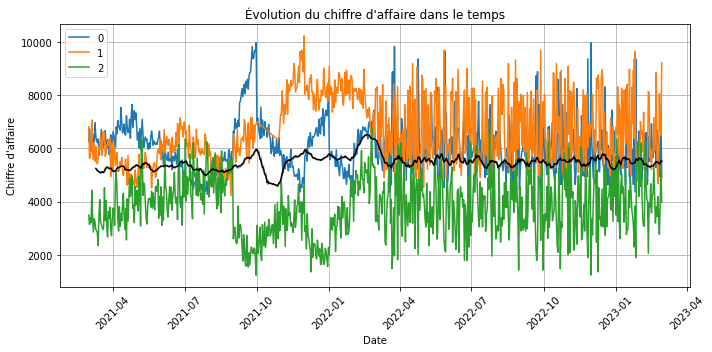

In [596]:
# Tracer évolution

plt.figure(figsize=(10, 5))
sns.lineplot(data=tend_nbTrans_cat, x="date_court", y="CA", hue="categ")
sns.lineplot(data=tend_nbTrans_cat, x="date_court", y="CA_moymob", color = "black")
#plt.plot(tend_nbTrans_cat["date_court"], tend_nbTrans_cat["CA"], marker = "o")
#plt.plot(tend_nbTrans_cat["date_court"], tend_nbTrans_cat["CA"].rolling(30).mean(), linestyle='-', color='red', label="Moyenne mobile 30 jours")

plt.title("Évolution du chiffre d'affaire dans le temps")
plt.xlabel("Date")
plt.ylabel("Chiffre d'affaire")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Enregistrer le graphique en PNG
plt.savefig("Evolution_CA.png", dpi=300, bbox_inches='tight')

plt.show()

In [597]:
# Chiffres clés
moy30_CA2 = round(tend_nbTrans_cat.loc[tend_nbTrans_cat["categ"]=="2", "CA_moymob"].mean(),2)
print(f"Le chiffre d'affaire moyen sur 30 jours {moy30_CA2} euros pour le categorie 2")

moy30_CA = round(tend_nbTrans_cat["CA_moymob"].mean(),2)
print(f"Le chiffre d'affaire moyen sur 30 jours {moy30_CA} euros")


#
tend_nbTrans = (
    trans_prod2
    .sort_values("date_court")
    .groupby(["date_court"])
    .agg(Nombre_trans=("session_id", "nunique"), 
        CA = ("price", "sum"), 
        Nombre_client = ("client_id", "nunique"))
    .reset_index()
)

# Chiffres clés
tend_nbTrans["CA_moymob"] = tend_nbTrans["CA"].rolling(1).mean()
tend_nbTrans["trans_moymob"] = tend_nbTrans["Nombre_trans"].rolling(1).mean()
tend_nbTrans["client_moymob"] = tend_nbTrans["Nombre_client"].rolling(1).mean()
moy_CA = round(tend_nbTrans["CA_moymob"].mean(),2)
moy_trans = round(tend_nbTrans["trans_moymob"].mean(),2)
moy_client = round(tend_nbTrans["client_moymob"].mean(),2)
print(f"Le chiffre d'affaire moyen par jour est {moy_CA} euros")
print(f"Le nombre de transaction moyen par jour est {moy_trans}")
print(f"Le nombre de client moyen par jour est {moy_client}")


Le chiffre d'affaire moyen sur 30 jours 5471.9 euros pour le categorie 2
Le chiffre d'affaire moyen sur 30 jours 5479.09 euros
Le chiffre d'affaire moyen par jour est 16241.54 euros
Le nombre de transaction moyen par jour est 471.1
Le nombre de client moyen par jour est 425.42


D'une manière globale, d'après la moyenne mobile sur 30 jours :
- Le chiffre d'affaires est stable autour de 5 479 euros sur toute la période.
- Le chiffre d'affaires des catégories 0 et 1 oscille entre 5 000 et 9 000 euros.
- Le chiffre d'affaires de la catégorie 2 varie entre 4 000 et 6 000 euros.

Entre septembre et novembre 2021 :

- La moyenne mobile sur 30 jours du chiffre d'affaires a connu une variation assez importante (hausse puis baisse), passant de 6 000 euros à moins de 5 000 euros. Les catégories 0 et 1 ont principalement contribué à cette baisse en septembre 2021, tandis que les catégories 1 et 2 ont favorisé l’augmentation observée en février 2022.
- Une légère hausse a été observée, passant de 5 500 euros à plus de 6 000 euros, toujours sur la moyenne mobile de 30 jours.

Comme pour le nombre de transactions, après novembre 2021, l’ampleur des chiffres d’affaires de toutes les catégories devient plus importante au quotidien.



 <div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jointure des données </h2>
</div>

<div style="background-color: RGB(51,100,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Etape 3.1 - Construire la table de transactions complète </h3>
</div>

#### Jointure transaction & clients

In [598]:
# Jointure gauche entre transaction & infos clients (parce qu'on veut connaitre les personnes qui ont acheté les produits)
trans_cust = pd.merge(transaction2, customer1, how="outer", left_on = "client_id", right_on = "client_id", indicator=True)
print(trans_cust["_merge"].unique()) # s'assurer qu'il y a que both & right_only

# Prendre les jointures internes uniquement
transCust = trans_cust.loc[trans_cust["_merge"]=="both"]
transCust = transCust.drop("_merge", axis=1)

transCust.info()

['both', 'right_only']
Categories (2, object): ['both', 'right_only']
<class 'pandas.core.frame.DataFrame'>
Int64Index: 679332 entries, 0 to 679331
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   index       679332 non-null  float64       
 1   id_prod     679332 non-null  object        
 2   date        679332 non-null  datetime64[ns]
 3   session_id  679332 non-null  object        
 4   client_id   679332 non-null  object        
 5   date_court  679332 non-null  datetime64[ns]
 6   year        679332 non-null  float64       
 7   quarter     679332 non-null  float64       
 8   month       679332 non-null  float64       
 9   sex         679332 non-null  object        
 10  birth       679332 non-null  int64         
 11  Age         679332 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(2), object(4)
memory usage: 67.4+ MB


In [599]:
print("Il y a {} valeur(s) nulle(s) en date.".format(transCust.loc[transCust["date"].isna()].shape[0]))

Il y a 0 valeur(s) nulle(s) en date.


#### Jointure transaction, client & produits

In [600]:
# Jointure gauche entre transaction_clients & infos product (parce qu'on veut connaitre les produits vendus)
trans_cust_prod = pd.merge(transCust, product2, how="outer", left_on = "id_prod", right_on = "id_prod", indicator=True)

print(trans_cust_prod["_merge"].unique()) # il n'y a plus de left_join

# Prendre uniquement les jointures interne
transCustProd = trans_cust_prod.loc[trans_cust_prod["_merge"]=="both"]

transCustProd.info()

['both', 'right_only']
Categories (2, object): ['both', 'right_only']
<class 'pandas.core.frame.DataFrame'>
Int64Index: 679332 entries, 0 to 679331
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   index_x     679332 non-null  float64       
 1   id_prod     679332 non-null  object        
 2   date        679332 non-null  datetime64[ns]
 3   session_id  679332 non-null  object        
 4   client_id   679332 non-null  object        
 5   date_court  679332 non-null  datetime64[ns]
 6   year        679332 non-null  float64       
 7   quarter     679332 non-null  float64       
 8   month       679332 non-null  float64       
 9   sex         679332 non-null  object        
 10  birth       679332 non-null  float64       
 11  Age         679332 non-null  float64       
 12  index_y     679332 non-null  int64         
 13  price       679332 non-null  float64       
 14  categ       679332 non-null  o

#### Ecriture du fichier "transactions" nettoyé

In [601]:
# Ecriture du fichier 
TCP = transCustProd.drop(["index_x", "index_y"], axis=1)
TCP.to_csv("Transaction_clean.csv", index=False)

TCP.head()

,id_prod,date,session_id,client_id,date_court,year,quarter,month,sex,birth,Age,price,categ,_merge
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,2022-05-20,2022.0,2.0,5.0,f,1986.0,39.0,4.18,0,both
1,0_1518,2021-07-20 13:21:29.043970,s_64849,c_103,2021-07-20,2021.0,3.0,7.0,f,1986.0,39.0,4.18,0,both
2,0_1518,2022-08-20 13:21:29.043970,s_255965,c_103,2022-08-20,2022.0,3.0,8.0,f,1986.0,39.0,4.18,0,both
3,0_1518,2021-05-09 11:52:55.100386,s_32104,c_6714,2021-05-09,2021.0,2.0,5.0,f,1968.0,57.0,4.18,0,both
4,0_1518,2022-05-30 01:17:07.487046,s_216118,c_6714,2022-05-30,2022.0,2.0,5.0,f,1968.0,57.0,4.18,0,both


In [602]:
# Chiffres clés
client_actif = TCP["client_id"].nunique()
CA = round(TCP["price"].sum(),2)
CAmoy = round(TCP["price"].mean(),2)
prod_vendu = TCP["id_prod"].nunique()
trans = TCP["session_id"].nunique()


In [603]:
# Chiffres clés
print(f"Nombre de client actif : {client_actif}")
print(f"Chiffre d'affaire : {CA} euros")
print(f"Nombre de produit vendu : {prod_vendu}")
print(f"Nombre de transaction : {trans}")
print(f"CA moyen : {CAmoy}")

Nombre de client actif : 8600
Chiffre d'affaire : 11856321.63 euros
Nombre de produit vendu : 3266
Nombre de transaction : 342315
CA moyen : 17.45


<div style="background-color: RGB(51,100,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Etape 3.2 - Construire la table de clients complète </h3>
</div>

#### Jointure transaction & clients

In [604]:
# Jointure gauche entre transaction & infos clients (parce qu'on veut connaitre les personnes qui ont acheté les produits)
cust_trans = pd.merge(transaction2, customer1, how="outer", left_on = "client_id", right_on = "client_id", indicator=True)
print(cust_trans["_merge"].unique()) # s'assurer qu'il y a que both & right_only

custTrans = cust_trans.drop("_merge", axis=1)

custTrans.info()

['both', 'right_only']
Categories (2, object): ['both', 'right_only']
<class 'pandas.core.frame.DataFrame'>
Int64Index: 679353 entries, 0 to 679352
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   index       679332 non-null  float64       
 1   id_prod     679332 non-null  object        
 2   date        679332 non-null  datetime64[ns]
 3   session_id  679332 non-null  object        
 4   client_id   679353 non-null  object        
 5   date_court  679332 non-null  datetime64[ns]
 6   year        679332 non-null  float64       
 7   quarter     679332 non-null  float64       
 8   month       679332 non-null  float64       
 9   sex         679353 non-null  object        
 10  birth       679353 non-null  int64         
 11  Age         679353 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(2), object(4)
memory usage: 67.4+ MB


#### Jointure client, transaction & produits

In [605]:
# Jointure gauche entre transaction_clients & infos product (parce qu'on veut connaitre les produits vendus)
cust_trans_prod = pd.merge(custTrans, product2, how="outer", left_on = "id_prod", right_on = "id_prod", indicator=True)

print(cust_trans_prod["_merge"].unique()) # il faut ignorer les right_only

# Prendre jointures contenant les infos de chaque client
custTransProd = cust_trans_prod.loc[(cust_trans_prod["_merge"]=="both") | (cust_trans_prod["_merge"]=="left_only")]

['both', 'left_only', 'right_only']
Categories (3, object): ['both', 'left_only', 'right_only']


In [606]:
custTransProd.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 679353 entries, 0 to 679352
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   index_x     679332 non-null  float64       
 1   id_prod     679332 non-null  object        
 2   date        679332 non-null  datetime64[ns]
 3   session_id  679332 non-null  object        
 4   client_id   679353 non-null  object        
 5   date_court  679332 non-null  datetime64[ns]
 6   year        679332 non-null  float64       
 7   quarter     679332 non-null  float64       
 8   month       679332 non-null  float64       
 9   sex         679353 non-null  object        
 10  birth       679353 non-null  float64       
 11  Age         679353 non-null  float64       
 12  index_y     679332 non-null  float64       
 13  price       679332 non-null  float64       
 14  categ       679332 non-null  object        
 15  _merge      679353 non-null  category      
dtypes:

In [607]:
# Groupement par client
trans_byClient = custTransProd.groupby(["client_id"]).agg(
    nombre_cat_prod = ("id_prod", "nunique"),
    nombre_achats = ("session_id", pd.Series.nunique),
    prix_moyen = ("price", "mean"),
    conso_total = ("price", "sum"),
    date_min=("date", "min"),
    date_max=("date", "max"), 
    age = ("Age", "mean"), 
    birth = ("birth", "first"), 
    genre = ("sex", "first")).reset_index()

trans_byClient.sort_values("nombre_cat_prod", ascending=False).head(5)

,client_id,nombre_cat_prod,nombre_achats,prix_moyen,conso_total,date_min,date_max,age,birth,genre
678,c_1609,1920,10997,12.713173,324033.350000,2021-03-01 00:07:04.371179,2023-02-28 22:29:54.677919,45.0,1980.0,m
6350,c_6714,1381,2620,16.726822,153669.316768,2021-03-01 06:44:06.269773,2023-02-28 23:10:49.235323,57.0,1968.0,f
2728,c_3454,1094,5573,16.783276,113673.128384,2021-03-01 01:08:49.803921,2023-02-28 23:16:12.006088,56.0,1969.0,m
4398,c_4958,467,3851,55.776774,289760.340000,2021-03-01 04:54:48.643575,2023-02-28 23:08:40.035146,26.0,1999.0,m
7808,c_8026,178,146,13.512766,5094.312795,2021-03-05 01:46:06.776568,2023-02-26 20:43:40.749868,47.0,1978.0,m


In [608]:
trans_byClient.loc[trans_byClient["prix_moyen"].isna(), "prix_moyen"] = 0
trans_byClient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   client_id        8621 non-null   object        
 1   nombre_cat_prod  8621 non-null   int64         
 2   nombre_achats    8621 non-null   int64         
 3   prix_moyen       8621 non-null   float64       
 4   conso_total      8621 non-null   float64       
 5   date_min         8600 non-null   datetime64[ns]
 6   date_max         8600 non-null   datetime64[ns]
 7   age              8621 non-null   float64       
 8   birth            8621 non-null   float64       
 9   genre            8621 non-null   object        
dtypes: datetime64[ns](2), float64(4), int64(2), object(2)
memory usage: 673.6+ KB


#### Ecriture du fichier "client" nettoyé

In [609]:
### Ecriture par client 
CTP = trans_byClient
CTP.to_csv("ClientTrans_clean.csv", index=False)

CTP.head()

,client_id,nombre_cat_prod,nombre_achats,prix_moyen,conso_total,date_min,date_max,age,birth,genre
0,c_1,19,33,14.312308,558.18,2021-06-11 21:02:39.382765,2023-01-15 20:46:25.222740,70.0,1955.0,m
1,c_10,27,34,23.337931,1353.60,2021-03-21 02:50:16.551727,2023-01-27 03:39:36.431524,69.0,1956.0,m
2,c_100,6,5,31.856250,254.85,2021-04-20 05:26:43.133053,2022-09-20 05:26:43.133053,33.0,1992.0,m
3,c_1000,52,93,18.095120,2261.89,2021-03-13 13:34:14.618755,2023-01-24 13:34:23.415697,59.0,1966.0,f
4,c_1001,56,47,17.773137,1812.86,2021-03-07 13:01:15.964197,2023-02-23 23:19:47.625822,43.0,1982.0,m


<div style="background-color: RGB(51,100,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Etape 3.3 - Construire la table de produits complète </h3>
</div>

#### Jointure transation & produit

In [610]:
# Jointure gauche entre transaction & infos clients (parce qu'on veut connaitre les personnes qui ont acheté les produits)
prod_trans = pd.merge(transaction2, product2, how="outer", left_on = "id_prod", right_on = "id_prod", indicator=True)
print(prod_trans["_merge"].unique()) 

prodTrans = prod_trans.drop("_merge", axis=1)

prodTrans.info()

['both', 'right_only']
Categories (2, object): ['both', 'right_only']
<class 'pandas.core.frame.DataFrame'>
Int64Index: 679353 entries, 0 to 679352
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   index_x     679332 non-null  float64       
 1   id_prod     679353 non-null  object        
 2   date        679332 non-null  datetime64[ns]
 3   session_id  679332 non-null  object        
 4   client_id   679332 non-null  object        
 5   date_court  679332 non-null  datetime64[ns]
 6   year        679332 non-null  float64       
 7   quarter     679332 non-null  float64       
 8   month       679332 non-null  float64       
 9   index_y     679353 non-null  int64         
 10  price       679353 non-null  float64       
 11  categ       679353 non-null  object        
dtypes: datetime64[ns](2), float64(5), int64(1), object(4)
memory usage: 67.4+ MB


#### Jointure transactions, produits et clients

In [611]:
# Jointure gauche entre transaction_clients & infos product (parce qu'on veut connaitre les produits vendus)
prod_trans_cust = pd.merge(prodTrans, customer1, how="outer", left_on = "client_id", right_on = "client_id", indicator=True)

print(prod_trans_cust["_merge"].unique()) # il faut ignorer les right_only

# Prendre jointures contenant les infos de chaque client
prodTransCust = prod_trans_cust.loc[(prod_trans_cust["_merge"]=="both") | (prod_trans_cust["_merge"]=="left_only")]


['both', 'left_only', 'right_only']
Categories (3, object): ['both', 'left_only', 'right_only']


In [612]:
trans_byProd = prodTransCust.groupby(["id_prod"]).agg(
    nombre_trans = ("session_id", "nunique"),
    nombre_clients = ("client_id", pd.Series.nunique),
    prix = ("price", "mean"),
    categ = ("categ", "first"),
    CA = ("price", "sum"),
    date_min=("date", "min"),
    date_max=("date", "max"))

trans_byProd.sort_values("nombre_clients", ascending=False).head(5)

,nombre_trans,nombre_clients,prix,categ,CA,date_min,date_max
id_prod,,,,,,,
1_369,2245,921,23.99,1,54025.48,2021-03-01 18:43:28.107416,2023-02-28 16:32:21.433069
1_417,2183,921,20.99,1,45947.11,2021-03-01 02:46:42.679910,2023-02-28 23:45:54.817107
1_414,2178,888,23.83,1,51949.40,2021-03-01 04:46:16.668266,2023-02-28 17:50:04.725589
1_498,2122,886,23.37,1,49731.36,2021-03-01 16:34:22.022846,2023-02-28 08:32:32.486023
1_425,2095,867,16.99,1,35611.04,2021-03-01 01:35:10.036602,2023-02-28 19:28:22.821734


In [613]:
trans_byProd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3287 entries, 0_0 to 2_99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   nombre_trans    3287 non-null   int64         
 1   nombre_clients  3287 non-null   int64         
 2   prix            3287 non-null   float64       
 3   categ           3287 non-null   object        
 4   CA              3287 non-null   float64       
 5   date_min        3266 non-null   datetime64[ns]
 6   date_max        3266 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(2), object(1)
memory usage: 205.4+ KB


#### Ecriture du fichier "produit" nettoyé

In [614]:
# Ecriture du fichier 
PTC = trans_byProd
PTC.to_csv("ProductTrans_clean.csv", index=False)

PTC.head()

,nombre_trans,nombre_clients,prix,categ,CA,date_min,date_max
id_prod,,,,,,,
0_0,1238,520,3.75,0,4657.50,2021-03-01 13:45:51.575117,2023-02-28 17:15:44.232323
0_1,487,230,10.99,0,5352.13,2021-03-01 21:27:12.080534,2023-02-27 05:00:22.579443
0_10,22,12,17.95,0,394.90,2021-03-04 06:33:45.330188,2023-02-09 23:08:27.237053
0_100,3,2,20.60,0,61.80,2021-09-17 01:55:36.439809,2023-01-06 20:52:21.946694
0_1000,432,199,6.84,0,2954.88,2021-03-01 02:24:57.000491,2023-02-26 22:47:06.580945


 <div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 -  Analyse descriptives </h2>
</div>

<div style="background-color: RGB(51,100,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Etape 4.1 - Analyse statistique "Transaction" </h3>
</div>

In [615]:
Trans = pd.read_csv("Transaction_clean.csv")
Trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679332 entries, 0 to 679331
Data columns (total 14 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id_prod     679332 non-null  object 
 1   date        679332 non-null  object 
 2   session_id  679332 non-null  object 
 3   client_id   679332 non-null  object 
 4   date_court  679332 non-null  object 
 5   year        679332 non-null  float64
 6   quarter     679332 non-null  float64
 7   month       679332 non-null  float64
 8   sex         679332 non-null  object 
 9   birth       679332 non-null  float64
 10  Age         679332 non-null  float64
 11  price       679332 non-null  float64
 12  categ       679332 non-null  int64  
 13  _merge      679332 non-null  object 
dtypes: float64(6), int64(1), object(7)
memory usage: 72.6+ MB


## Analyse de tendance 

In [616]:
Trans["categ"] = Trans["categ"].astype("str")
Trans["date_court"] = pd.to_datetime(Trans["date_court"], errors='coerce')

In [617]:
# Analyse de tendance de nombre de vente
tend_nbTrans = (
    Trans
    .sort_values("date_court")
    .groupby("date_court")
    .agg(Nombre_trans=("session_id", "nunique"), 
        CA = ("price", "sum"),
        CA_moyen = ("price", "mean"))
    .reset_index()
)

# Changer en type date
tend_nbTrans["date_court"] = pd.to_datetime(tend_nbTrans["date_court"])


#### Evolution de nombre de transaction

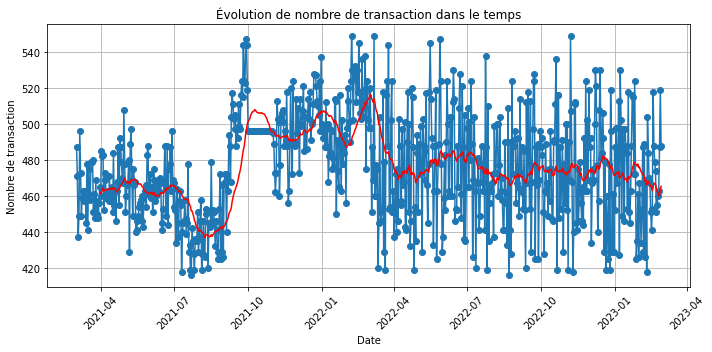

In [618]:
# Tracer une graphique de nombre de transaction corrigée des anomalies
# Obtenir le nombre de transaction du mois d'avant et d'après
nbTrans_sep = tend_nbTrans.loc[(tend_nbTrans["date_court"]>="2021-09-01") & (tend_nbTrans["date_court"]<="2021-09-30"), "Nombre_trans"].mean()
nbTrans_nov = tend_nbTrans.loc[(tend_nbTrans["date_court"]>="2021-11-01") & (tend_nbTrans["date_court"]<="2021-11-30"), "Nombre_trans"].mean()

# Le nombre de transaction est la moyenne de ces 2 mois
tend_nbTrans.loc[(tend_nbTrans["date_court"]>="2021-10-01") & (tend_nbTrans["date_court"]<="2021-10-31"), "Nombre_trans"] = round((nbTrans_sep+nbTrans_nov)/2, 2)


plt.figure(figsize=(10, 5))
plt.plot(tend_nbTrans["date_court"], tend_nbTrans["Nombre_trans"], marker='o')
plt.plot(tend_nbTrans["date_court"], tend_nbTrans["Nombre_trans"].rolling(30).mean(), linestyle='-', color='red', label="Moyenne mobile 30 jours")

plt.title('Évolution de nombre de transaction dans le temps')
plt.xlabel('Date')
plt.ylabel('Nombre de transaction')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Anomalie du mois d'octobre est corrigé: forte baisse de vente en 2021-10

#### Evolution de CA 

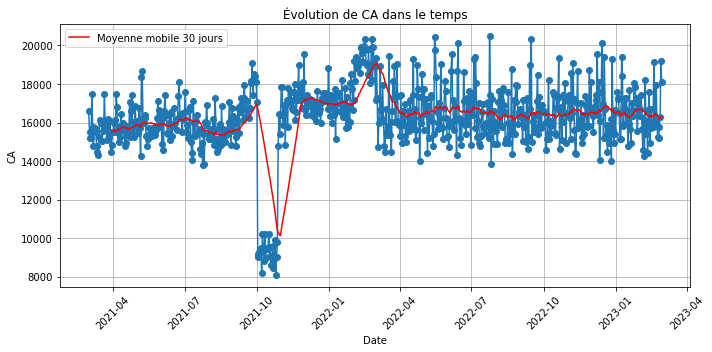

In [619]:
# Tracer
plt.figure(figsize=(10, 5))
plt.plot(tend_nbTrans["date_court"], tend_nbTrans["CA"], marker='o')
plt.plot(tend_nbTrans["date_court"], tend_nbTrans["CA"].rolling(30).mean(), linestyle='-', color='red', label="Moyenne mobile 30 jours")

plt.title('Évolution de CA dans le temps')
plt.xlabel('Date')
plt.ylabel('CA')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()

plt.savefig("Evolution_CA.png", dpi=300, bbox_inches='tight')
plt.show()

#### Evolution de CA corrigée

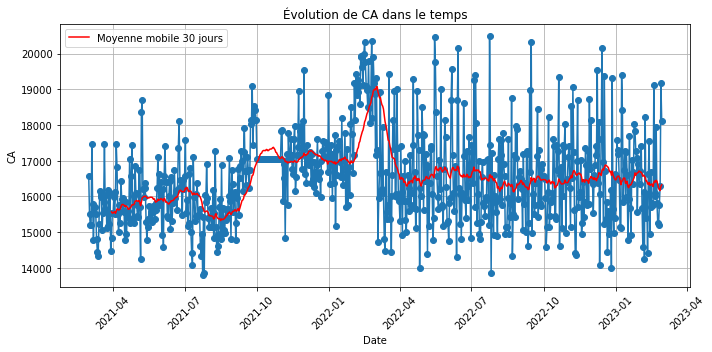

In [620]:
# Tracer l'évolution de CA corrigée

# Obtenir le CA du mois d'avant et d'après
CA_sep = tend_nbTrans.loc[(tend_nbTrans["date_court"]>="2021-09-01") & (tend_nbTrans["date_court"]<="2021-09-30"), "CA"].mean()
CA_nov = tend_nbTrans.loc[(tend_nbTrans["date_court"]>="2021-11-01") & (tend_nbTrans["date_court"]<="2021-11-30"), "CA"].mean()

# Le CA est la moyenne de ces 2 mois
tend_nbTrans.loc[(tend_nbTrans["date_court"]>="2021-10-01") & (tend_nbTrans["date_court"]<="2021-10-31"), "CA"] = round((CA_sep+CA_nov)/2, 2)


# Tracer
plt.figure(figsize=(10, 5))
plt.plot(tend_nbTrans["date_court"], tend_nbTrans["CA"], marker='o')
plt.plot(tend_nbTrans["date_court"], tend_nbTrans["CA"].rolling(30).mean(), linestyle='-', color='red', label="Moyenne mobile 30 jours")

plt.title('Évolution de CA dans le temps')
plt.xlabel('Date')
plt.ylabel('CA')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()


plt.show()


- Anomalie en octobre 2021 est corrigée. On remarque que le CA a beaucoup augmenté entre 2022-02 et 2022-03, atteigant un pic de moyen mobile à 19 000 euros. Après cette augmentation la moyenne mobile sur 30 jours se stabilise entre 16 000 et 17 000, alors qu'avant elle était plutôt autour de 15 000 - 16 000 euros.

#### Evolution de CA par catégorie

In [621]:
# CA par date et catégorie
tend_nbTrans_cat = (
    Trans
    .sort_values("date_court")
    .groupby(["date_court", "categ"])
    .agg(Nombre_trans=("session_id", "nunique"), 
        CA = ("price", "sum"))
    .reset_index()
)

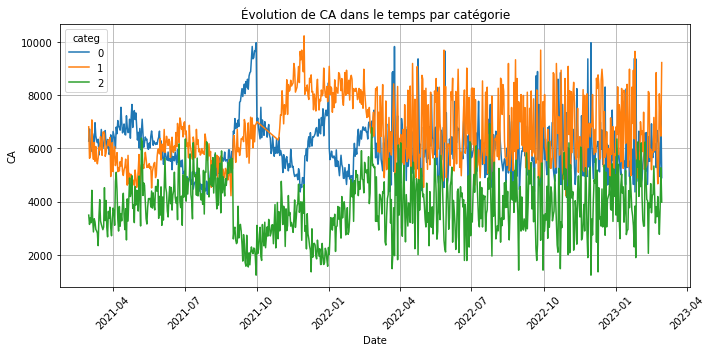

In [622]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=tend_nbTrans_cat, x='date_court', y='CA', hue='categ')

plt.title('Évolution de CA dans le temps par catégorie')
plt.xlabel('Date')
plt.ylabel('CA')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<div style="background-color: RGB(51,100,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Etape 4.2 - Analyse statistique "Produit" </h3>
</div>

In [623]:
# CA par categorie 
Trans_prod = Trans.groupby(["id_prod"]).agg(
    CA =("price", "sum"),
    prix_mean =("price", "mean"),
    nb_ligne=("session_id", "count"),
    nb_achat =("session_id", "nunique"),
    prod_nb =("id_prod", "nunique"),
    client_nb =("client_id", "nunique")
).reset_index()

Trans_prod.head(5)
Trans_prod.sort_values(by = "CA", ascending = False).head(10)

,id_prod,CA,prix_mean,nb_ligne,nb_achat,prod_nb,client_nb
3097,2_159,94893.50,145.99,650,649,1,530
3071,2_135,69334.95,68.99,1005,994,1,402
3046,2_112,65407.76,67.57,968,960,1,383
3035,2_102,60736.78,59.14,1027,1025,1,402
3153,2_209,56971.86,69.99,814,814,1,316
2620,1_395,54356.25,28.99,1875,1873,1,768
2592,1_369,54025.48,23.99,2252,2245,1,921
3044,2_110,53846.25,62.25,865,865,1,357
3202,2_39,53060.85,57.99,915,915,1,356
3105,2_166,52449.12,230.04,228,228,1,99


#### Top 5 produits vendus

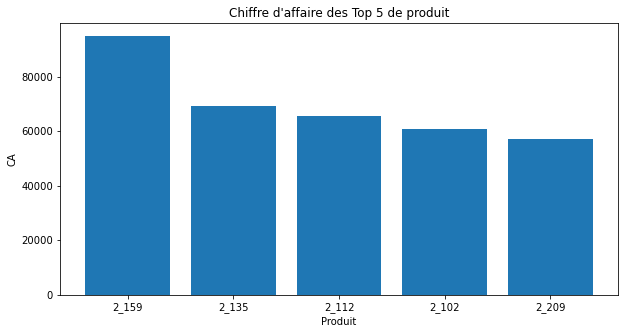

In [624]:
# Visualisation par produit des Top 5
top5_prod = Trans_prod.sort_values(by = "CA", ascending = False).head(5)
plt.figure(figsize=(10, 5))
plt.bar(top5_prod["id_prod"],top5_prod["CA"])
plt.title("Chiffre d'affaire des Top 5 de produit")
plt.xlabel('Produit')
plt.ylabel('CA')
plt.grid(False)


# Enregistrer le graphique en PNG
plt.savefig("Top5_prod.png", dpi=300, bbox_inches='tight')
plt.show()


#### Flop 5 produits vendus

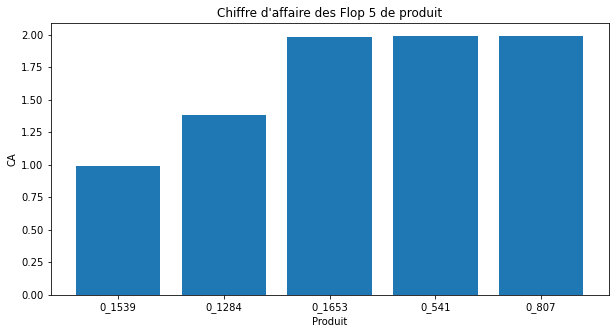

In [625]:
# Flop 5 produits
flop5_prod = Trans_prod.sort_values(by = "CA", ascending = True).head(5)
plt.figure(figsize=(10, 5))
plt.bar(flop5_prod["id_prod"],flop5_prod["CA"])
plt.title("Chiffre d'affaire des Flop 5 de produit")
plt.xlabel('Produit')
plt.ylabel('CA')
plt.grid(False)


# Enregistrer le graphique en PNG
plt.savefig("Flop5_prod.png", dpi=300, bbox_inches='tight')
plt.show()

- Les tops de CA proviennent généralement de catégorie 2 et les flop de CA de catégorie 0

#### Chiffres clés par catégorie

In [682]:
# CA par categorie 
Trans_cat = Trans.groupby(["categ"]).agg(
    prix_sum =("price", "sum"),
    prix_mean =("price", "mean"),
    trans=("session_id", "count"),
    session_nb=("session_id", "nunique"),
    prod_nb =("id_prod", "nunique"),
    client_nb =("client_id", "nunique")
).reset_index()

print("Tableau résumant la vente des produits par catégorie :")
Trans_cat

Tableau résumant la vente des produits par catégorie


,categ,prix_sum,prix_mean,trans,session_nb,prod_nb,client_nb
0,0,4.422324e+06,10.638770,415680,225500,2293,7896
1,1,4.653723e+06,20.485730,227169,179216,737,8453
2,2,2.780275e+06,76.207412,36483,30574,236,3597


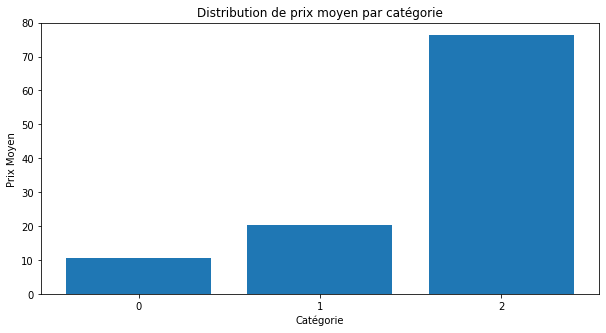

In [627]:
plt.figure(figsize=(10, 5))
plt.bar(Trans_cat["categ"],Trans_cat["prix_mean"])
plt.title('Distribution de prix moyen par catégorie')
plt.xlabel('Catégorie')
plt.ylabel('Prix Moyen')
plt.grid(False)
plt.show()


- Prix moyen de la catégorie 0 est de 10 euros alors que celle de 2 peut aller jusqu'à 76 euros.

#### Comparaison de CA des produits vendus

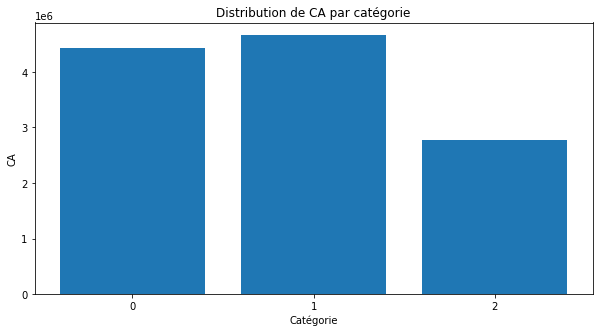

In [628]:
# Visualisation CA par categorie
plt.figure(figsize=(10, 5))
plt.bar(Trans_cat["categ"],Trans_cat["prix_sum"])
plt.title('Distribution de CA par catégorie')
plt.xlabel('Catégorie')
plt.ylabel('CA')
plt.grid(False)
plt.show()


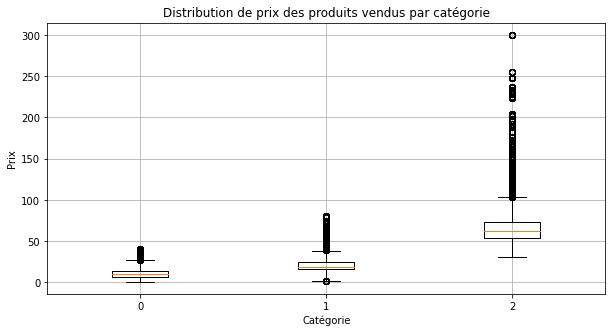

In [678]:
data = [group["price"].values for _, group in Trans.groupby("categ")]

plt.figure(figsize=(10, 5))
plt.boxplot(data, labels=Trans["categ"].unique())
plt.title('Distribution de prix des produits vendus par catégorie')
plt.xlabel('Catégorie')
plt.ylabel('Prix')
plt.grid(True)


plt.savefig("boxplot_prixMean.png", dpi=300, bbox_inches='tight')
plt.show()


#### Validation d'effet de Pareto 80/20 sur les produits vendus

In [630]:
def lorenz_curve(data):
    sorted_data = np.sort(data)
    cum_data = np.cumsum(sorted_data)
    cum_data = np.insert(cum_data, 0, 0)
    cum_data = cum_data / cum_data[-1]  # Normalisé entre 0 et 1
    x = np.linspace(0, 1, len(cum_data))
    return x, cum_data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nombre_trans    3287 non-null   int64  
 1   nombre_clients  3287 non-null   int64  
 2   prix            3287 non-null   float64
 3   categ           3287 non-null   int64  
 4   CA              3287 non-null   float64
 5   date_min        3266 non-null   object 
 6   date_max        3266 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 179.9+ KB


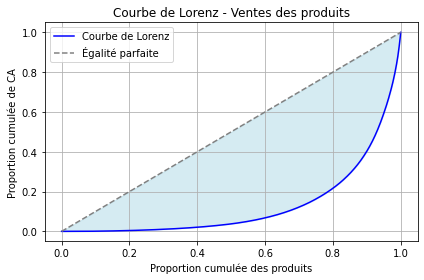

In [631]:
# Chargement de l'ensemble des clients
Prod = pd.read_csv("ProductTrans_clean.csv")
Prod.info()

# Indice Gini & Courbe Lorenz Produit 
x, y = lorenz_curve(Prod["CA"])

plt.plot(x, y, label="Courbe de Lorenz", color='blue')
plt.plot([0, 1], [0, 1], '--', label="Égalité parfaite", color='gray')
plt.fill_between(x, x, y, color='lightblue', alpha=0.5)

plt.title("Courbe de Lorenz - Ventes des produits")
plt.xlabel("Proportion cumulée des produits")
plt.ylabel("Proportion cumulée de CA")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Enregistrer le graphique en PNG
plt.savefig("Lorenz_prod.png", dpi=300, bbox_inches='tight')

plt.show()

In [632]:
x, y = lorenz_curve(Trans_prod["CA"])
B = np.trapz(y, x)
gini = 1 - 2 * B

print(f"Indice de Gini : {gini:.3f}")

Indice de Gini : 0.743


L'effet de Pareto 80/20 est clairement observable dans les produits vendus. La courbe de Lorenz s’éloigne fortement de la droite d’égalité parfaite.
- On peut lire sur le graphique que seuls 20 % des produits représentent 80 % du chiffre d’affaires.



<div style="background-color: RGB(51,100,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Etape 4.3 - Analyse statistique "Client" </h3>
</div>

#### Par client

In [633]:
# CA par client
Trans_client = Trans.groupby("client_id").agg(
    conso_total =("price", "sum"),
    prix_mean =("price", "mean"),
    nb_ligne=("session_id", "count"),
    session_nb=("session_id", "nunique"),
    prod_nb =("id_prod", "nunique"),
    client_nb =("client_id", "nunique")
).reset_index()

Trans_client.head(2)

,client_id,conso_total,prix_mean,nb_ligne,session_nb,prod_nb,client_nb
0,c_1,558.18,14.312308,39,33,19,1
1,c_10,1353.60,23.337931,58,34,27,1


#### Top 10 clients consommateurs

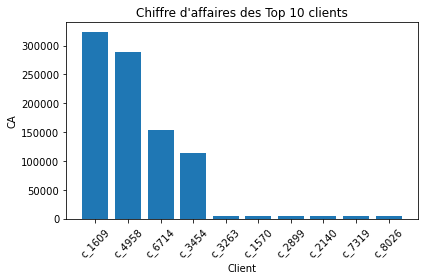

In [634]:
# Top client
top10cust_conso = Trans_client.sort_values("conso_total", ascending=False).head(10)

plt.bar(top10cust_conso["client_id"], top10cust_conso["conso_total"])
plt.title("Chiffre d'affaires des Top 10 clients")
plt.grid(False)
plt.xlabel("Client")
plt.ylabel("CA")
plt.xticks(rotation=45)
plt.tight_layout()

# Enregistrer le graphique en PNG
plt.savefig("top10_client.png", dpi=300, bbox_inches='tight')
plt.show()

- 4 clients achètent une volume de CA dépassant largement les autres clients, ils devront être les clients BtoB.

#### Flop 5 clients consommateurs

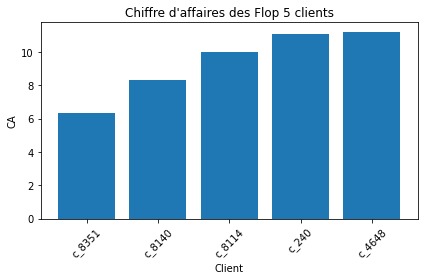

In [635]:
# Flop client
flop5cust_conso = Trans_client.sort_values("conso_total", ascending=True).head(5)

plt.bar(flop5cust_conso["client_id"], flop5cust_conso["conso_total"])
plt.title("Chiffre d'affaires des Flop 5 clients")
plt.grid(False)
plt.xlabel("Client")
plt.ylabel("CA")
plt.xticks(rotation=45)
plt.tight_layout()

# Enregistrer le graphique en PNG
plt.savefig("flop5_client.png", dpi=300, bbox_inches='tight')
plt.show()

In [636]:
Trans.head(2)

,id_prod,date,session_id,client_id,date_court,year,quarter,month,sex,birth,Age,price,categ,_merge
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,2022-05-20,2022.0,2.0,5.0,f,1986.0,39.0,4.18,0,both
1,0_1518,2021-07-20 13:21:29.043970,s_64849,c_103,2021-07-20,2021.0,3.0,7.0,f,1986.0,39.0,4.18,0,both


#### Par tranche d'âge

In [637]:
list_clients = ["c_1609", "c_4958", "c_6714", "c_3454"]
transaction = Trans[~Trans["client_id"].isin(list_clients)].reset_index()


In [638]:
# Créer une tranche d'age 
transaction["Age_tranche"] = pd.cut(transaction["Age"],
                       bins=[transaction["Age"].min(), 30, 50, 70, transaction["Age"].max()],  # bornes
                       labels=["20-30", "30-50", "50-70", "70+"],  # noms de tranche
                       right=False)

In [639]:
# CA par tranche
# Creer une tranche age
Trans_age = transaction.groupby("Age_tranche").agg(
    prix_sum =("price", "sum"),
    prix_mean =("price", "mean"),
    nb_ligne=("session_id", "count"),
    session_nb=("session_id", "nunique"),
    prod_nb =("id_prod", "nunique"),
    client_nb =("client_id", "nunique")
).reset_index()

Trans_age = Trans_age.sort_values(by="Age_tranche").reset_index()

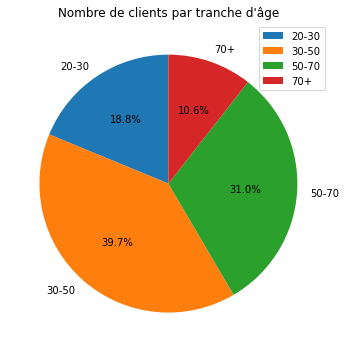

In [640]:
# Visualisation de nombre de client par tranche d'âge
plt.figure(figsize=(10, 5))
plt.pie(Trans_age["client_nb"], labels=Trans_age["Age_tranche"], autopct='%1.1f%%', startangle=90)
plt.title("Nombre de clients par tranche d\'âge")
plt.grid(False)
plt.tight_layout()
plt.legend()

# Enregistrer le graphique en PNG
plt.savefig("pie_nb_trancheAge.png", dpi=300, bbox_inches='tight')
plt.show()


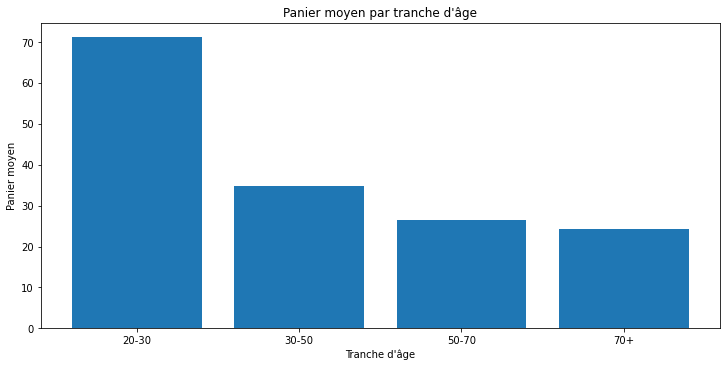

In [641]:
# Visualisation de panier moyen par tranche d'âge
plt.figure(figsize=(10, 5))
plt.bar(Trans_age["Age_tranche"], Trans_age["prix_sum"]/Trans_age["session_nb"])
plt.title("Panier moyen par tranche d\'âge")
plt.grid(False)
plt.tight_layout()
plt.xlabel("Tranche d'âge")
plt.ylabel("Panier moyen")



# Enregistrer le graphique en PNG
plt.savefig("bar_CA_trancheAge.png", dpi=300, bbox_inches='tight')
plt.show()

#### Par genre 

In [642]:
# CA par genre
Trans_genre = Trans.groupby("sex").agg(
    prix_sum =("price", "sum"),
    prix_mean =("price", "mean"),
    nb_ligne=("session_id", "count"),
    session_nb=("session_id", "nunique"),
    prod_nb =("id_prod", "nunique"),
    client_nb =("client_id", "nunique")
).reset_index()

Trans_genre.head(2)

,sex,prix_sum,prix_mean,nb_ligne,session_nb,prod_nb,client_nb
0,f,5.861056e+06,17.319803,338402,169457,3178,4479
1,m,5.995266e+06,17.585034,340930,172858,3180,4121


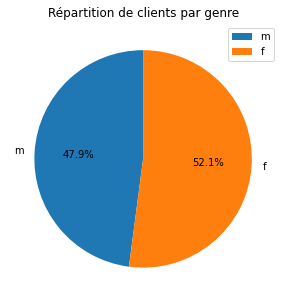

In [643]:
# Visualisation de CA par genre
Trans_genre = Trans_genre.sort_values("sex", ascending=False)

plt.figure(figsize=(10, 5))
plt.pie(Trans_genre["client_nb"], labels = Trans_genre["sex"],autopct='%1.1f%%', startangle=90)
plt.title('Répartition de clients par genre')
plt.legend()
plt.grid(False)

# Enregistrer le graphique en PNG
plt.savefig("bar_cust_Genre.png", dpi=300, bbox_inches='tight')
plt.show()


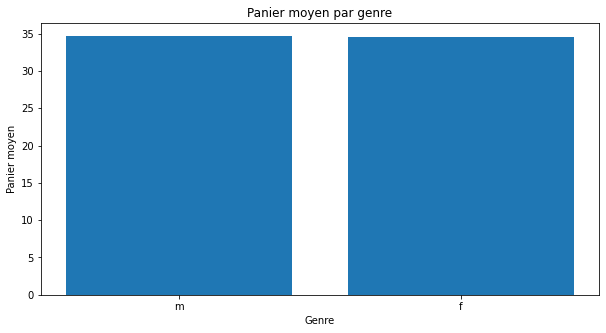

In [644]:
# Visualisation de panier moyen par genre
plt.figure(figsize=(10, 5))
plt.bar(Trans_genre["sex"],Trans_genre["prix_sum"]/Trans_genre["session_nb"])
plt.title('Panier moyen par genre')
plt.xlabel('Genre')
plt.ylabel('Panier moyen')
plt.grid(False)

# Enregistrer le graphique en PNG
plt.savefig("bar_ConsoMoy_Genre.png", dpi=300, bbox_inches='tight')
plt.show()

#### Table de contingence en CA : Catégorie de produits & genre de clients

In [645]:
# Table de contingence CA
tableCA_genreCateg = pd.crosstab(Trans['sex'], Trans['categ'], values=Trans['price'], aggfunc='sum', margins = True)

tableCA_genreCateg_ptg = pd.crosstab(Trans['sex'], Trans['categ'], values=Trans['price'], aggfunc='sum', normalize='index')
round(tableCA_genreCateg_ptg*100,2)

categ,0,1,2
sex,,,
f,37.39,40.24,22.37
m,37.21,38.29,24.50


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   client_id        8621 non-null   object 
 1   nombre_cat_prod  8621 non-null   int64  
 2   nombre_achats    8621 non-null   int64  
 3   prix_moyen       8621 non-null   float64
 4   conso_total      8621 non-null   float64
 5   date_min         8600 non-null   object 
 6   date_max         8600 non-null   object 
 7   age              8621 non-null   float64
 8   birth            8621 non-null   float64
 9   genre            8621 non-null   object 
dtypes: float64(4), int64(2), object(4)
memory usage: 673.6+ KB


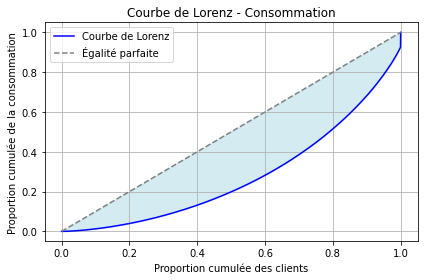

In [646]:
# Chargement de l'ensemble des clients
Customer = pd.read_csv("ClientTrans_clean.csv")
Customer.info()


# Courbe de Lorenz 
x, y = lorenz_curve(Customer["conso_total"])

plt.plot(x, y, label="Courbe de Lorenz", color='blue')
plt.plot([0, 1], [0, 1], '--', label="Égalité parfaite", color='gray')
plt.fill_between(x, x, y, color='lightblue', alpha=0.5)

plt.title("Courbe de Lorenz - Consommation")
plt.xlabel("Proportion cumulée des clients")
plt.ylabel("Proportion cumulée de la consommation")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("Courbe_Lorenz_client.png",dpi=300, bbox_inches='tight')
plt.show()
# Cumul decroissant

In [647]:
x, y = lorenz_curve(Customer["conso_total"])
B = np.trapz(y, x)
gini = 1 - 2 * B

print(f"Indice de Gini : {gini:.3f}")

Indice de Gini : 0.448


- Une inégalité de niveau de consommation entre les clients est de 44,8%. 
- La courbe de Lorenz veut dire que 80% des clients ont consommé 50% de CA dans ce librarie. Il n'existe pas d'effet de Pareto à grand ampleur comme pour les produits !

 <div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 -  Tests statistiques </h2>
</div>

Tests étudiant la corrélation entre :
- Genre & catégories des livres achetés
- Age des clients & montant total des achats
- Age des clients & fréquence d’achat
- Age des clients & taille du panier moyen
- Age des clients & catégorie des livres achetés;

In [648]:
# Importation 
# Infos de transactions
Trans = pd.read_csv("Transaction_clean.csv")


<div style="background-color: RGB(51,100,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Clients - détection des anomalies </h3>
</div>

#### Détection des anomalies

In [649]:
# Detecter les anomalies
# Méthode de détection des outliers par Quantile
def detect_outliers(df, feature) : 
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3-Q1
    
    return(df[feature]< (Q1 - 2*IQR)) | (df[feature]> (Q3 + 2*IQR))


In [650]:
# regroupe par clients
client_CA = (
    Trans
    .groupby(["client_id"])
    .agg(CA=("price", "sum"), 
        Nb_trans = ("session_id", "nunique"), 
        Nb_clients = ("client_id", "nunique"), 
        Nb_prod_vendu = ("id_prod", "nunique"))
    .reset_index()
)

client_CA.head(2)

,client_id,CA,Nb_trans,Nb_clients,Nb_prod_vendu
0,c_1,558.18,33,1,19
1,c_10,1353.60,34,1,27


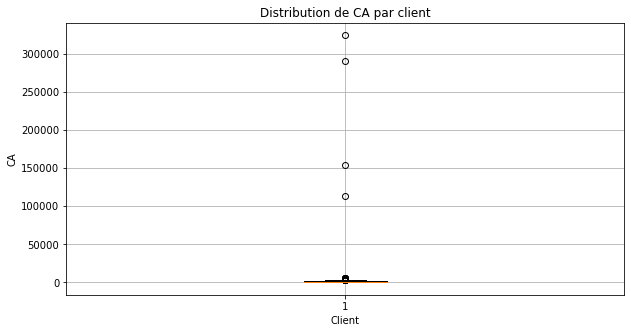

In [651]:
# CA par client
plt.figure(figsize=(10, 5))
plt.boxplot(client_CA["CA"])
plt.title('Distribution de CA par client')
plt.xlabel('Client')
plt.ylabel('CA')
plt.grid(True)
plt.show()

Les CA anormalement élevés écrasent les autres données.

In [652]:
print("Les clients à enlever lors d'étude de test de corrélation sont de:", client_CA.loc[detect_outliers(client_CA, "CA"), "client_id"].shape[0], "\n", client_CA.loc[detect_outliers(client_CA, "CA"), "client_id"])
list_clients = client_CA.loc[detect_outliers(client_CA, "CA"), "client_id"]


Les clients à enlever lors d'étude de test de corrélation sont de: 85 
 167     c_1149
409     c_1368
460     c_1413
470     c_1422
634     c_1570
         ...  
8356    c_8537
8377    c_8556
8427    c_8600
8469     c_880
8560     c_963
Name: client_id, Length: 85, dtype: object


In [653]:
# Enleve les outliers définie par la fonction détection outliers
Transm = Trans.loc[~Trans["client_id"].isin(list_clients)]  #["c_1609", "c_4958", "c_6714", "c_3454"]

client_CAm = (
    Transm
    .groupby(["client_id"])
    .agg(CA=("price", "sum"), 
        Nb_trans = ("session_id", "nunique"), 
        Nb_clients = ("client_id", "nunique"), 
        Nb_prod_vendu = ("id_prod", "nunique"),
        date_min = ("date_court", "min"),
        date_max = ("date_court", "max"), 
        genre = ("sex", "last"), 
        age = ("Age", "last"))
    .reset_index()
)

# Calculer le panier moyen
client_CAm["Panier_moyen"] = client_CAm["CA"]/client_CAm["Nb_trans"]


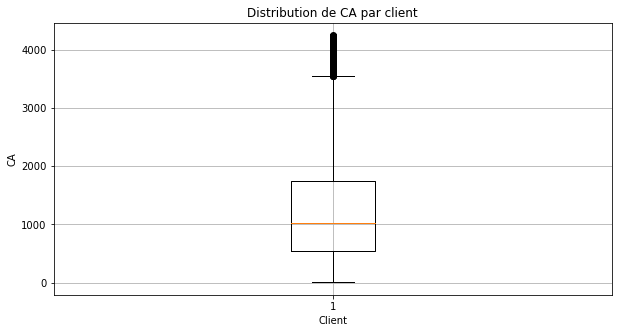

In [654]:
# Box plot modifié
plt.figure(figsize=(10, 5))
plt.boxplot(client_CAm["CA"])
plt.title('Distribution de CA par client')
plt.xlabel('Client')
plt.ylabel('CA')
plt.grid(True)
plt.show()

In [655]:
client_CAm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8515 entries, 0 to 8514
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   client_id      8515 non-null   object 
 1   CA             8515 non-null   float64
 2   Nb_trans       8515 non-null   int64  
 3   Nb_clients     8515 non-null   int64  
 4   Nb_prod_vendu  8515 non-null   int64  
 5   date_min       8515 non-null   object 
 6   date_max       8515 non-null   object 
 7   genre          8515 non-null   object 
 8   age            8515 non-null   float64
 9   Panier_moyen   8515 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 665.4+ KB


In [656]:
# Supprimer les clients anormales observés 
Customer1 = Customer.loc[~Customer["client_id"].isin(list_clients)] #["c_1609", "c_4958", "c_6714", "c_3454"]
Customer1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8536 entries, 0 to 8620
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   client_id        8536 non-null   object 
 1   nombre_cat_prod  8536 non-null   int64  
 2   nombre_achats    8536 non-null   int64  
 3   prix_moyen       8536 non-null   float64
 4   conso_total      8536 non-null   float64
 5   date_min         8515 non-null   object 
 6   date_max         8515 non-null   object 
 7   age              8536 non-null   float64
 8   birth            8536 non-null   float64
 9   genre            8536 non-null   object 
dtypes: float64(4), int64(2), object(4)
memory usage: 733.6+ KB


<div style="background-color: RGB(51,100,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; "> Tests statistiques </h3>
</div>

### Normalité

Test de normalité des données pour décider quel test utilisé :
- si les données suivent une loi normale alors on peut utiliser les tests paramétriques (Pearson, Test T, ANOVA)
- sinon, les tests non paramétriques (Spearman, Test U, Kruskall Wallis)


Test de normalité : 
- H0 : Données de distribution normale
- H1 : Données de distrbution non normale 

**p-value (probabilité de se tromper si on rejette H0) :**
 - **Si p-value > 5% alors la probabilité de se tromper est forte si on rejette H0 => On accepte H0.**

Le test de normalité Shapiro-Wilk sert pour de petites données, stable et en alternative on peut utiliser le test Kolmogorov-Smirnov.

In [657]:
# Normalité des données 

def normalite(col_data) :
    print(f"Taille de l'échantillon: {len(col_data)}")
    data = col_data.dropna()
    if len(data)>2000:
      # Standardisation avant le test KS
        data_std = (data - data.mean()) / data.std()
        stat, p_value = kstest(data_std, 'norm')
        print("Test de Kolmogorov-Smirnov (standardisé)") 
    else:
        stat, p_value = shapiro(data)
        print("Test de Shapiro-Wilk")
    
    
    print(f"Statistique KS: {stat}")
    print(f"p-value: {p_value}")
    
    # Interprétation des résultats
        # Si p_value <= 0.05 alors distribution différent de la distribution normale 
        # Hypothèse null : les données suivent la distribution normale rejetée

    alpha = 0.05
    if p_value > alpha:
        print("Les données suivent une distribution normale (on ne rejette pas H0)")
    else:
        print("Les données ne suivent pas une distribution normale (on rejette H0)")

    return stat, p_value

In [658]:
normalite(Trans["price"])

Taille de l'échantillon: 679332
Test de Kolmogorov-Smirnov (standardisé)
Statistique KS: 0.23202701344885712
p-value: 0.0
Les données ne suivent pas une distribution normale (on rejette H0)


(0.23202701344885712, 0.0)

In [659]:
normalite(client_CAm["CA"])
print("")
normalite(client_CAm["age"])
print("")
normalite(client_CAm["Nb_trans"])
print("")
normalite(client_CAm["Panier_moyen"])

# Aucun ne suit la distribution normale

Taille de l'échantillon: 8515
Test de Kolmogorov-Smirnov (standardisé)
Statistique KS: 0.1012160154191063
p-value: 2.1386832943451655e-76
Les données ne suivent pas une distribution normale (on rejette H0)

Taille de l'échantillon: 8515
Test de Kolmogorov-Smirnov (standardisé)
Statistique KS: 0.06403988811636127
p-value: 8.387277294142385e-31
Les données ne suivent pas une distribution normale (on rejette H0)

Taille de l'échantillon: 8515
Test de Kolmogorov-Smirnov (standardisé)
Statistique KS: 0.15085617637825088
p-value: 1.2130337580426053e-169
Les données ne suivent pas une distribution normale (on rejette H0)

Taille de l'échantillon: 8515
Test de Kolmogorov-Smirnov (standardisé)
Statistique KS: 0.1880453818962633
p-value: 4.230560747578309e-264
Les données ne suivent pas une distribution normale (on rejette H0)


(0.1880453818962633, 4.230560747578309e-264)

#### Normalité de consommation par client

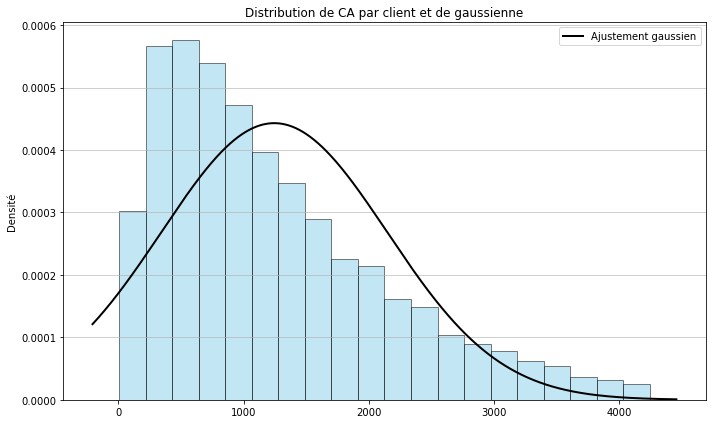

In [660]:
# Paramètres de la distribution normale 
col_data = client_CAm["CA"].dropna()

# Histogramme de données CA
plt.figure(figsize=(10,6))
plt.hist(col_data, bins=20, density=True, color="skyblue", edgecolor = "black", alpha=0.5)

# Courbe gaussienne
mu, sigma = norm.fit(col_data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, len(col_data))
p = norm.pdf(x, mu, sigma)

plt.plot(x, p, "k", linewidth=2, label= "Ajustement gaussien")
plt.legend()

plt.title("Distribution de CA par client et de gaussienne")
plt.ylabel("Densité")
plt.grid(axis="y", alpha = 0.75)
plt.tight_layout()

# Enregistrer le graphique en PNG
plt.savefig("Densite_CAclient_gauss.png", dpi=300, bbox_inches='tight')

plt.show()

#### Normalité d'âge

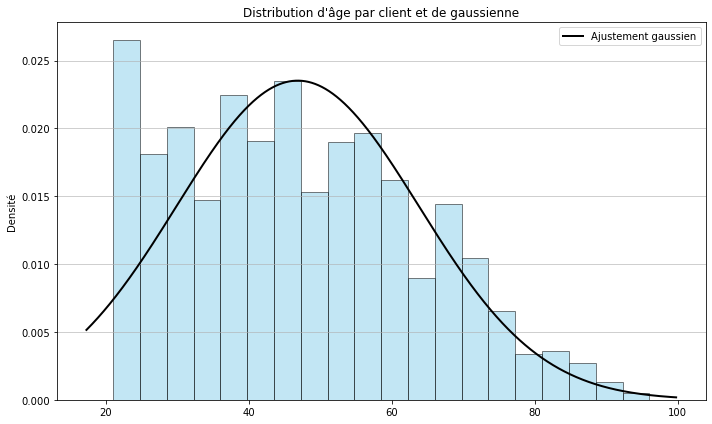

In [661]:
# Paramètres de la distribution normale 
col_data = client_CAm["age"].dropna()

# Histogramme de données CA
plt.figure(figsize=(10,6))
plt.hist(col_data, bins=20, density=True, color="skyblue", edgecolor = "black", alpha=0.5)

# Courbe gaussienne
mu, sigma = norm.fit(col_data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, len(col_data))
p = norm.pdf(x, mu, sigma)

plt.plot(x, p, "k", linewidth=2, label= "Ajustement gaussien")
plt.legend()

plt.title("Distribution d'âge par client et de gaussienne")
plt.ylabel("Densité")
plt.grid(axis="y", alpha = 0.75)
plt.tight_layout()

# Enregistrer le graphique en PNG
plt.savefig("Densite_Ageclient_gauss.png", dpi=300, bbox_inches='tight')

plt.show()

#### Normalité de nombre de transaction 

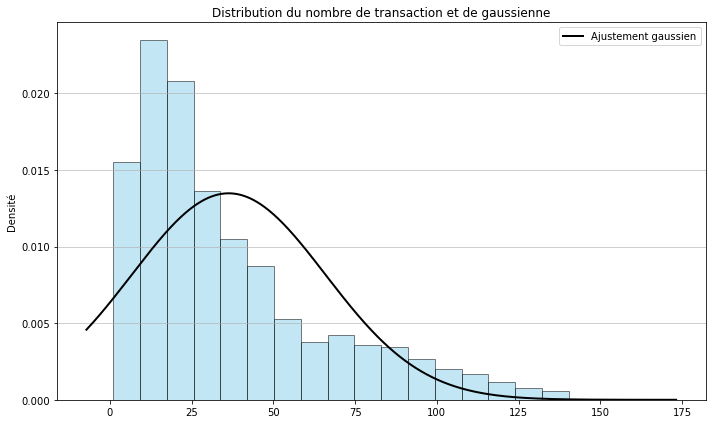

In [662]:
col_data = client_CAm["Nb_trans"].dropna()

# Histogramme de données CA
plt.figure(figsize=(10,6))
plt.hist(col_data, bins=20, density=True, color="skyblue", edgecolor = "black", alpha=0.5)

# Courbe gaussienne
mu, sigma = norm.fit(col_data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, len(col_data))
p = norm.pdf(x, mu, sigma)

plt.plot(x, p, "k", linewidth=2, label= "Ajustement gaussien")
plt.legend()

plt.title("Distribution du nombre de transaction et de gaussienne")
plt.ylabel("Densité")
plt.grid(axis="y", alpha = 0.75)
plt.tight_layout()

# Enregistrer le graphique en PNG
plt.savefig("Densite_nbTrans_gauss.png", dpi=300, bbox_inches='tight')

plt.show()

#### Normalité de panier moyen

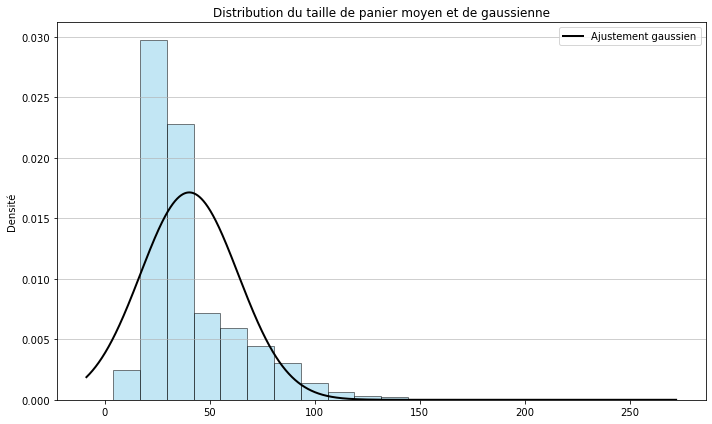

In [663]:
col_data = client_CAm["Panier_moyen"].dropna()

# Histogramme de données CA
plt.figure(figsize=(10,6))
plt.hist(col_data, bins=20, density=True, color="skyblue", edgecolor = "black", alpha=0.5)

# Courbe gaussienne
mu, sigma = norm.fit(col_data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, len(col_data))
p = norm.pdf(x, mu, sigma)

plt.plot(x, p, "k", linewidth=2, label= "Ajustement gaussien")
plt.legend()

plt.title("Distribution du taille de panier moyen et de gaussienne")
plt.ylabel("Densité")
plt.grid(axis="y", alpha = 0.75)
plt.tight_layout()

# Enregistrer le graphique en PNG
plt.savefig("Densite_PanierMoy_gauss.png", dpi=300, bbox_inches='tight')
plt.show()

## Test de corrélation qualitatives 

#### Genre & categorie de produit

Test qualitative : 
Fisher (pour table de contingence 2x2, échantillon de petite taille):
- odds ratios : si supérieur ou inférieur à 1 alors une dépendance positive ou négative (!=0)

Chi-2 (table de contingence 2x3, etc., échantillon de plus grande taille) : 
- H0 : La variable 1 est indépendante au variable 2.
- H1 : Les 2 variables sont dépendantes.

In [664]:
# Choix de test X^2 pour déterminer si une distribution observée de données catégorielle est différente d'une distribution attendeue
# Construire une table de contingence (2x3)
from scipy.stats import chi2_contingency

data = Transm[["sex", "categ"]].dropna()

# Table de contingence
table = pd.crosstab(data["sex"], data["categ"])

print(table)

categ       0       1      2
sex                         
f      192622  108606  16595
m      177168   98014  15459


In [665]:
# Test du chi2
chi2, p, dof, expected = chi2_contingency(table)

print(f"Statistique de Chi² : {chi2}")
print(f"p-value : {p}")
print(f"Degrés de liberté : {dof}")
print("Fréquences attendues :\n", expected)

# Si p<= 0.05 alors rejette l'hypothèse indépendance (H0)

Statistique de Chi² : 14.806445796249665
p-value : 0.0006092859269075627
Degrés de liberté : 2
Fréquences attendues :
 [[193154.84099306 107925.18252518  16742.97648176]
 [176635.15900694  98694.81747482  15311.02351824]]


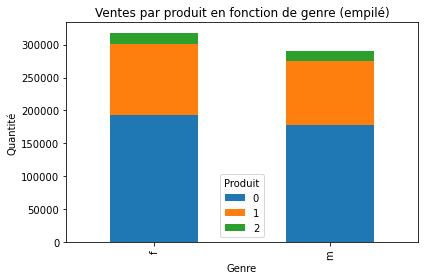

<Figure size 432x288 with 0 Axes>

In [689]:
# Barre empilé 
ax = table.plot(kind='bar', stacked=True)

plt.title("Ventes par produit en fonction de genre (empilé)")
plt.ylabel("Quantité")
plt.xlabel("Genre")
plt.legend(title="Produit")
plt.tight_layout()

plt.show()

# Enregistrer le graphique en PNG
plt.savefig("Barre_empile_ProdGenre.png", dpi=300, bbox_inches='tight')
plt.show()



- On rejette l'hypothèse de "H0 : les 2 variables sont indépendantes"

## Test de corrélation quantitatives 

#### Age & Consommation total

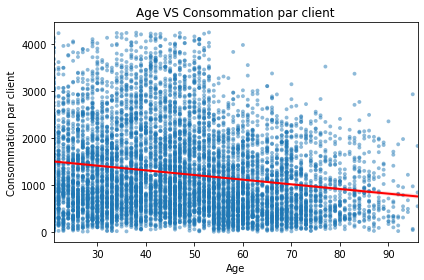

In [667]:
dfCus = client_CAm[["age", "CA"]].dropna()

sns.scatterplot(data=dfCus, x="age", y="CA", alpha=0.5, s=15, edgecolor='none')
sns.regplot(x = "age", y = "CA", data = dfCus, scatter = False, line_kws={'color':'red',  'linewidth': 2})
plt.title("Age VS Consommation par client")
plt.xlabel("Age")
plt.ylabel("Consommation par client")
plt.grid(False)
plt.tight_layout()

# Enregistrer le graphique en PNG
plt.savefig("scatter_ageConso.png", dpi=300, bbox_inches='tight')
plt.show()

Spearman : 
- H0 : Affirme qu'il n'y a pas de corrélation linéraire entre les 2 variables quantitatives
- H1 : Il y a bien une corrélation linéaire entre les 2 variables
- Si p-value>5% alors rejette H1.

In [668]:
from scipy.stats import spearmanr

rho, p = spearmanr(dfCus["age"], dfCus["CA"])
print(f"Coefficient de Spearman: {rho}, p_value: {p}, Si p_value < 5%, alors on rejette H0 : {p<0.05}")

Coefficient de Spearman: -0.18199184023769277, p_value: 2.5808467588491225e-64, Si p_value < 5%, alors on rejette H0 : True


- On rejette H0 : "Affirme qu'il n'y a pas de corrélation linéraire entre les 2 variables quantitatives"

#### Age & nombre de transaction

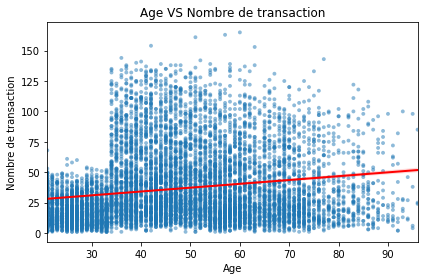

In [669]:
age_trans = client_CAm[["age", "Nb_trans"]].dropna()

sns.scatterplot(data=age_trans, x="age", y="Nb_trans", alpha=0.5, s=15, edgecolor="none")
sns.regplot(x = "age", y = "Nb_trans", data = age_trans, scatter = False, line_kws={'color':'red',  'linewidth': 2})
plt.title("Age VS Nombre de transaction")
plt.xlabel("Age")
plt.ylabel("Nombre de transaction")
plt.grid(False)
plt.tight_layout()

# Enregistrer le graphique en PNG
plt.savefig("scatter_ageTrans.png", dpi=300, bbox_inches='tight')
plt.show()

In [670]:
from scipy.stats import spearmanr

rho, p = spearmanr(client_CAm["age"], client_CAm["Nb_trans"])
print(f"Coefficient de Spearman: {rho}, p_value: {p}, Si p_value < 5%, alors on rejette H0 : {p<0.05}")

Coefficient de Spearman: 0.21929121070271226, p_value: 3.0968053061976056e-93, Si p_value < 5%, alors on rejette H0 : True


- On rejette H0 : "Affirme qu'il n'y a pas de corrélation linéraire entre les 2 variables quantitatives"

#### Age & taille de panier moyen

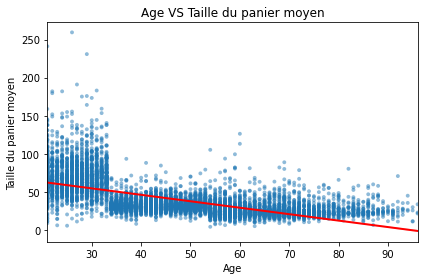

In [671]:
age_panier = client_CAm[["age", "Panier_moyen"]].dropna()

sns.scatterplot(data=age_panier, x="age", y="Panier_moyen", alpha=0.5, s=15, edgecolor="none")
sns.regplot(x = "age", y = "Panier_moyen", data = age_panier, scatter = False, line_kws={'color':'red',  'linewidth': 2})
plt.title("Age VS Taille du panier moyen")
plt.xlabel("Age")
plt.ylabel("Taille du panier moyen")
plt.grid(False)
plt.tight_layout()

# Enregistrer le graphique en PNG
plt.savefig("scatter_agePanier.png", dpi=300, bbox_inches='tight')
plt.show()

In [672]:
from scipy.stats import spearmanr

rho, p = spearmanr(client_CAm["age"], client_CAm["Panier_moyen"])
print(f"Coefficient de Spearman: {rho}, p_value: {p}, Si p_value < 5%, alors on rejette H0 : {p<0.05}")

Coefficient de Spearman: -0.701115274506871, p_value: 0.0, Si p_value < 5%, alors on rejette H0 : True


- On rejette H0 : "Affirme qu'il n'y a pas de corrélation linéraire entre les 2 variables quantitatives"

## Test de corrélation mixtes

#### Age & catégorie de livres achetés

In [673]:
# Test KW
from scipy.stats import kruskal

# 2 groupes et tester si 2 groupes suivent les mêmes distributions
data = Transm[["categ", "Age"]].dropna()

# Séparer les groupes
groupe_0 = data[data["categ"]=="0"]["Age"]
groupe_1 = data[data["categ"]=="1"]["Age"]
groupe_2 = data[data["categ"]=="2"]["Age"]


# Test Kruskal-Wallis
groupes = [group["Age"].values for name, group in data.groupby("categ")]

# Test de Kruskal-Wallis
stat, p = kruskal(*groupes)

print("Statistique H de Kruskal-Wallis :", stat)
print("p-value :", p)

if p < 0.05:
    print("→ Il existe une différence significative entre les groupes.")
else:
    print("→ Aucune différence significative détectée entre les groupes.")

Statistique H de Kruskal-Wallis : 70380.53261918155
p-value : 0.0
→ Il existe une différence significative entre les groupes.


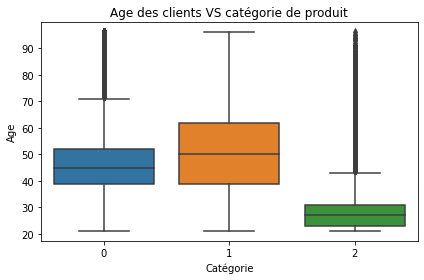

In [674]:
sns.boxplot(x="categ", y="Age", data=data)
plt.title("Age des clients VS catégorie de produit")
plt.grid(False)

plt.xlabel("Catégorie")
plt.ylabel("Age")
plt.tight_layout()

# Enregistrer le graphique en PNG
plt.savefig("boxplot_catAge.png", dpi=300, bbox_inches='tight')
plt.show()

 <div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">FIN DE NOTEBOOK </h2>
</div>